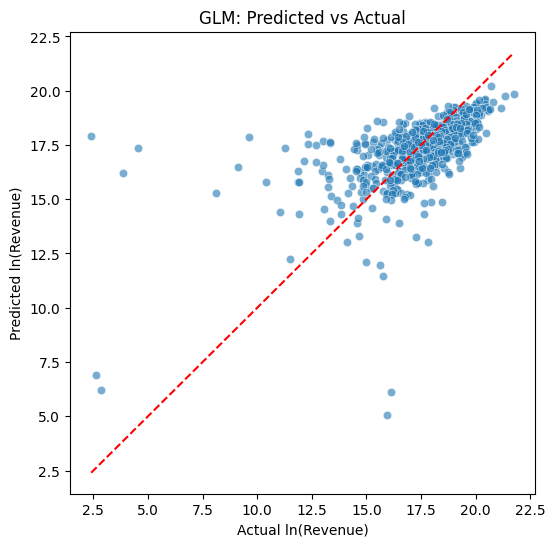

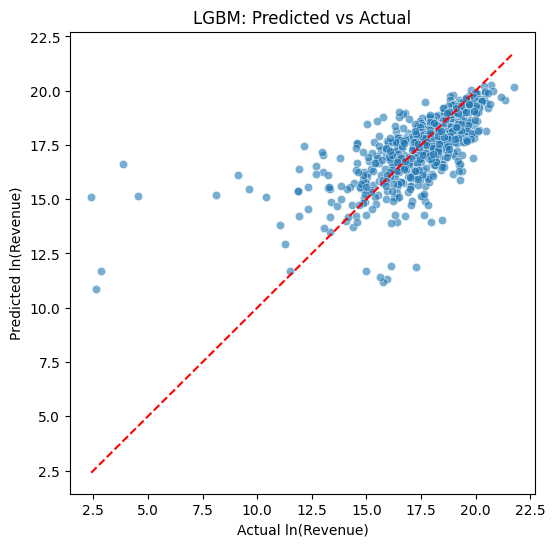

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

from _load_predictions import load_predict_parquet

df = load_predict_parquet()

def plot_pred_vs_actual(df, pred_col, actual_col='ln_revenue', model_name='Model'):
    plt.figure(figsize=(6,6))
    sns.scatterplot(x=df[actual_col], y=df[pred_col], alpha=0.6)
    plt.plot([df[actual_col].min(), df[actual_col].max()],
             [df[actual_col].min(), df[actual_col].max()],
             'r--')
    plt.xlabel("Actual ln(Revenue)")
    plt.ylabel("Predicted ln(Revenue)")
    plt.title(f"{model_name}: Predicted vs Actual")
    plt.show()

plot_pred_vs_actual(df, 'pred_glm', model_name='GLM')
plot_pred_vs_actual(df, 'pred_lgbm', model_name='LGBM')


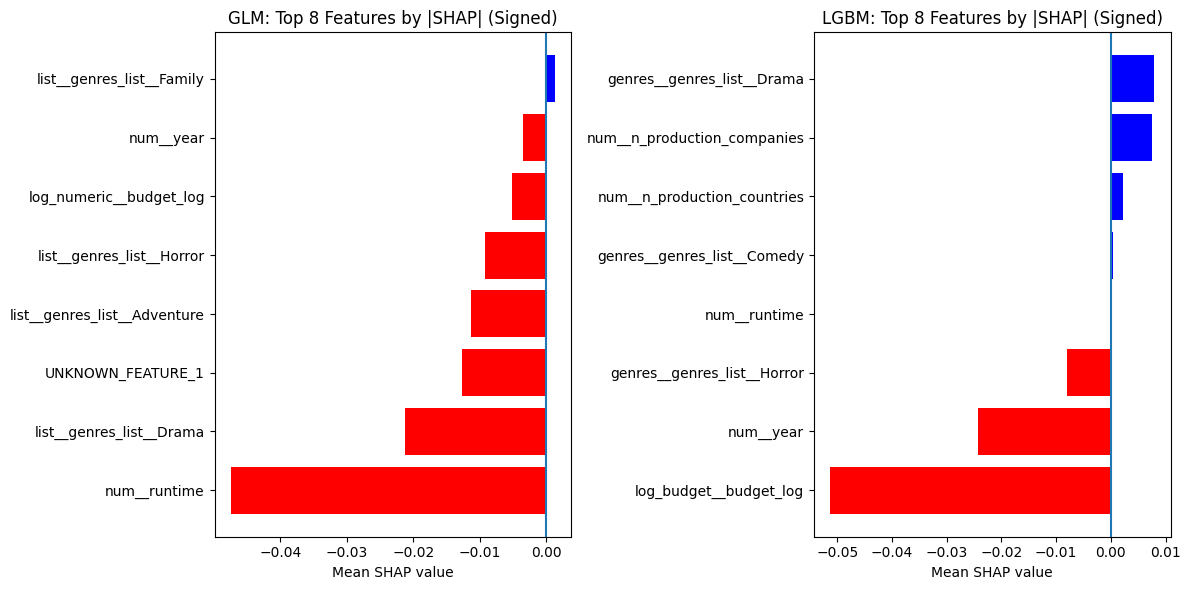

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def load_prepare_abs_select_signed(path, top_n=8):
    # Load SHAP values
    data = np.load(path, allow_pickle=True).item()
    shap_vals = data["shap_values"]
    feature_names = list(data["feature_names"])

    # Pad feature names if needed
    if shap_vals.shape[1] > len(feature_names):
        feature_names += [f"UNKNOWN_FEATURE_{i}" for i in range(shap_vals.shape[1] - len(feature_names))]

    shap_df = pd.DataFrame(shap_vals, columns=feature_names)

    # Compute mean absolute and mean signed
    mean_abs = shap_df.abs().mean()
    mean_signed = shap_df.mean()

    # Select top N by absolute SHAP
    top_features = mean_abs.nlargest(top_n).index
    top_signed = mean_signed.loc[top_features]

    # Sort for plotting (smallest signed at bottom, largest at top)
    top_signed_sorted = top_signed.sort_values()

    # Colors
    colors = ['red' if v < 0 else 'blue' for v in top_signed_sorted]

    return top_signed_sorted, colors

# Load GLM and LGBM
glm_vals, glm_colors = load_prepare_abs_select_signed("shap_values_glm_with_names.npy", 8)
lgbm_vals, lgbm_colors = load_prepare_abs_select_signed("shap_values_lgbm_with_names.npy", 8)

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.barh(glm_vals.index, glm_vals.values, color=glm_colors)
plt.axvline(0)
plt.title("GLM: Top 8 Features by |SHAP| (Signed)")
plt.xlabel("Mean SHAP value")

plt.subplot(1, 2, 2)
plt.barh(lgbm_vals.index, lgbm_vals.values, color=lgbm_colors)
plt.axvline(0)
plt.title("LGBM: Top 8 Features by |SHAP| (Signed)")
plt.xlabel("Mean SHAP value")

plt.tight_layout()
plt.show()


Loaded LGBM model and preprocessor.
PDP feature: log_budget__budget_log (index 0)


/home/gmurp/miniconda3/envs/d100projectenv/lib/python3.12/site-packages/sklearn/pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/home/gmurp/miniconda3/envs/d100projectenv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/gmurp/miniconda3/envs/d100projectenv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/gmurp/miniconda3/envs/d100projectenv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home

<Figure size 800x600 with 0 Axes>

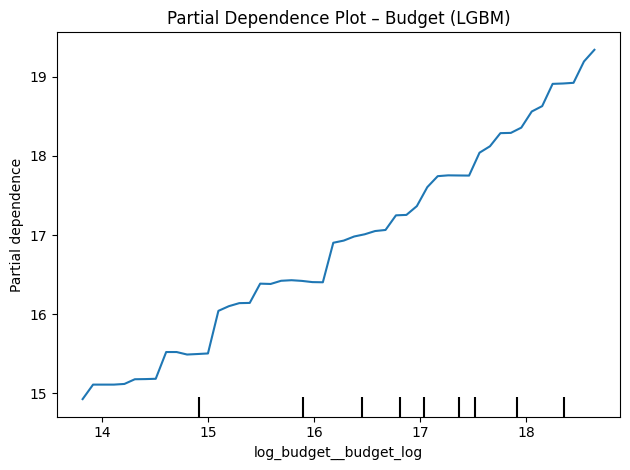

In [5]:
import sys
from pathlib import Path

# --------------------------------------------------
# Project root
# --------------------------------------------------
project_root = Path.cwd().resolve().parents[1]
sys.path.insert(0, str(project_root))

# --------------------------------------------------
# Imports
# --------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from joblib import load
from sklearn.inspection import PartialDependenceDisplay

# --------------------------------------------------
# Paths
# --------------------------------------------------
evaluation_dir = project_root / "d100project" / "evaluation"

# --------------------------------------------------
# Load model & preprocessor
# --------------------------------------------------
lgbm_model = load(evaluation_dir / "lgbm_model.joblib")
preprocessor_lgbm = load(evaluation_dir / "lgbm_preprocessor.joblib")

print("Loaded LGBM model and preprocessor.")

# --------------------------------------------------
# Load evaluation data
# --------------------------------------------------
df = pd.read_parquet(evaluation_dir / "df_test_with_predictions.parquet")

# --------------------------------------------------
# Feature definitions (MUST match training)
# --------------------------------------------------
numeric_features = ["budget", "runtime", "year"]
list_features = ["genres_list"]
high_cardinality = ["original_language"]
count_features = [
    "n_production_companies",
    "n_production_countries",
    "n_spoken_languages"
]
month_feature = "month"

all_features = (
    numeric_features
    + list_features
    + [month_feature]
    + high_cardinality
    + count_features
)

X = df[all_features]

# --------------------------------------------------
# Transform data
# --------------------------------------------------
X_lgbm = preprocessor_lgbm.transform(X)

# --------------------------------------------------
# Get transformed feature names
# --------------------------------------------------
feature_names = preprocessor_lgbm.get_feature_names_out()

# --------------------------------------------------
# Select ONE feature for PDP (budget)
# --------------------------------------------------
# PDP must be done on transformed features
target_feature = "budget"

feature_name = [
    f for f in feature_names if target_feature in f.lower()
][0]

feature_index = list(feature_names).index(feature_name)

print(f"PDP feature: {feature_name} (index {feature_index})")

# --------------------------------------------------
# Plot PDP
# --------------------------------------------------
plt.figure(figsize=(8, 6))

PartialDependenceDisplay.from_estimator(
    lgbm_model,
    X_lgbm,
    features=[feature_index],
    feature_names=feature_names,
    grid_resolution=50
)

plt.title("Partial Dependence Plot – Budget (LGBM)")
plt.tight_layout()
plt.show()


Loaded LGBM model and preprocessor.
PDP feature: num__year (index 2)


/home/gmurp/miniconda3/envs/d100projectenv/lib/python3.12/site-packages/sklearn/pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/home/gmurp/miniconda3/envs/d100projectenv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/gmurp/miniconda3/envs/d100projectenv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/gmurp/miniconda3/envs/d100projectenv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home

<Figure size 800x600 with 0 Axes>

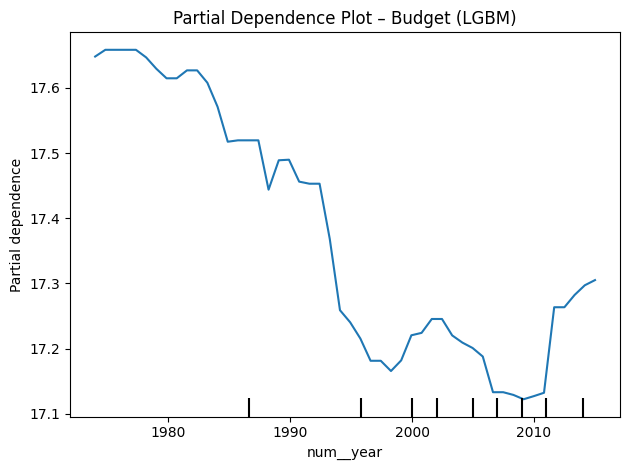

In [6]:
import sys
from pathlib import Path

# --------------------------------------------------
# Project root
# --------------------------------------------------
project_root = Path.cwd().resolve().parents[1]
sys.path.insert(0, str(project_root))

# --------------------------------------------------
# Imports
# --------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from joblib import load
from sklearn.inspection import PartialDependenceDisplay

# --------------------------------------------------
# Paths
# --------------------------------------------------
evaluation_dir = project_root / "d100project" / "evaluation"

# --------------------------------------------------
# Load model & preprocessor
# --------------------------------------------------
lgbm_model = load(evaluation_dir / "lgbm_model.joblib")
preprocessor_lgbm = load(evaluation_dir / "lgbm_preprocessor.joblib")

print("Loaded LGBM model and preprocessor.")

# --------------------------------------------------
# Load evaluation data
# --------------------------------------------------
df = pd.read_parquet(evaluation_dir / "df_test_with_predictions.parquet")

# --------------------------------------------------
# Feature definitions (MUST match training)
# --------------------------------------------------
numeric_features = ["budget", "runtime", "year"]
list_features = ["genres_list"]
high_cardinality = ["original_language"]
count_features = [
    "n_production_companies",
    "n_production_countries",
    "n_spoken_languages"
]
month_feature = "month"

all_features = (
    numeric_features
    + list_features
    + [month_feature]
    + high_cardinality
    + count_features
)

X = df[all_features]

# --------------------------------------------------
# Transform data
# --------------------------------------------------
X_lgbm = preprocessor_lgbm.transform(X)

# --------------------------------------------------
# Get transformed feature names
# --------------------------------------------------
feature_names = preprocessor_lgbm.get_feature_names_out()

# --------------------------------------------------
# Select ONE feature for PDP (budget)
# --------------------------------------------------
# PDP must be done on transformed features
target_feature = "year"

feature_name = [
    f for f in feature_names if target_feature in f.lower()
][0]

feature_index = list(feature_names).index(feature_name)

print(f"PDP feature: {feature_name} (index {feature_index})")

# --------------------------------------------------
# Plot PDP
# --------------------------------------------------
plt.figure(figsize=(8, 6))

PartialDependenceDisplay.from_estimator(
    lgbm_model,
    X_lgbm,
    features=[feature_index],
    feature_names=feature_names,
    grid_resolution=50
)

plt.title("Partial Dependence Plot – Budget (LGBM)")
plt.tight_layout()
plt.show()

Loaded LGBM model and preprocessor.
PDP feature: num__n_production_companies (index 3)


/home/gmurp/miniconda3/envs/d100projectenv/lib/python3.12/site-packages/sklearn/pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/home/gmurp/miniconda3/envs/d100projectenv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/gmurp/miniconda3/envs/d100projectenv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/gmurp/miniconda3/envs/d100projectenv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home

<Figure size 800x600 with 0 Axes>

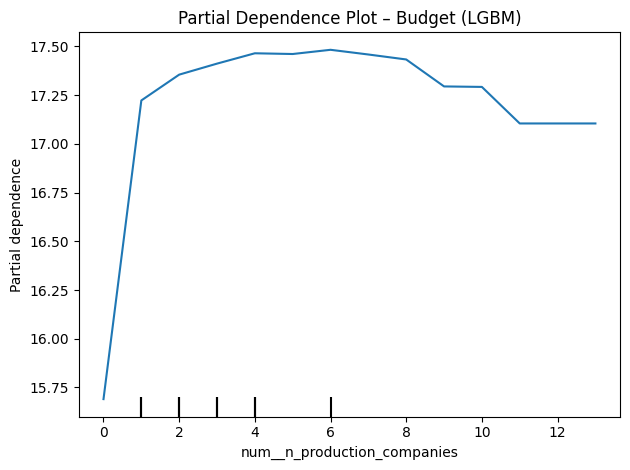

In [7]:
import sys
from pathlib import Path

# --------------------------------------------------
# Project root
# --------------------------------------------------
project_root = Path.cwd().resolve().parents[1]
sys.path.insert(0, str(project_root))

# --------------------------------------------------
# Imports
# --------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from joblib import load
from sklearn.inspection import PartialDependenceDisplay

# --------------------------------------------------
# Paths
# --------------------------------------------------
evaluation_dir = project_root / "d100project" / "evaluation"

# --------------------------------------------------
# Load model & preprocessor
# --------------------------------------------------
lgbm_model = load(evaluation_dir / "lgbm_model.joblib")
preprocessor_lgbm = load(evaluation_dir / "lgbm_preprocessor.joblib")

print("Loaded LGBM model and preprocessor.")

# --------------------------------------------------
# Load evaluation data
# --------------------------------------------------
df = pd.read_parquet(evaluation_dir / "df_test_with_predictions.parquet")

# --------------------------------------------------
# Feature definitions (MUST match training)
# --------------------------------------------------
numeric_features = ["budget", "runtime", "year"]
list_features = ["genres_list"]
high_cardinality = ["original_language"]
count_features = [
    "n_production_companies",
    "n_production_countries",
    "n_spoken_languages"
]
month_feature = "month"

all_features = (
    numeric_features
    + list_features
    + [month_feature]
    + high_cardinality
    + count_features
)

X = df[all_features]

# --------------------------------------------------
# Transform data
# --------------------------------------------------
X_lgbm = preprocessor_lgbm.transform(X)

# --------------------------------------------------
# Get transformed feature names
# --------------------------------------------------
feature_names = preprocessor_lgbm.get_feature_names_out()

# --------------------------------------------------
# Select ONE feature for PDP (budget)
# --------------------------------------------------
# PDP must be done on transformed features
target_feature = "n_production_companies"

feature_name = [
    f for f in feature_names if target_feature in f.lower()
][0]

feature_index = list(feature_names).index(feature_name)

print(f"PDP feature: {feature_name} (index {feature_index})")

# --------------------------------------------------
# Plot PDP
# --------------------------------------------------
plt.figure(figsize=(8, 6))

PartialDependenceDisplay.from_estimator(
    lgbm_model,
    X_lgbm,
    features=[feature_index],
    feature_names=feature_names,
    grid_resolution=50
)

plt.title("Partial Dependence Plot – Budget (LGBM)")
plt.tight_layout()
plt.show()

Loaded LGBM model and preprocessor.
PDP feature: num__n_production_countries (index 4)


/home/gmurp/miniconda3/envs/d100projectenv/lib/python3.12/site-packages/sklearn/pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/home/gmurp/miniconda3/envs/d100projectenv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/gmurp/miniconda3/envs/d100projectenv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/gmurp/miniconda3/envs/d100projectenv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home

<Figure size 800x600 with 0 Axes>

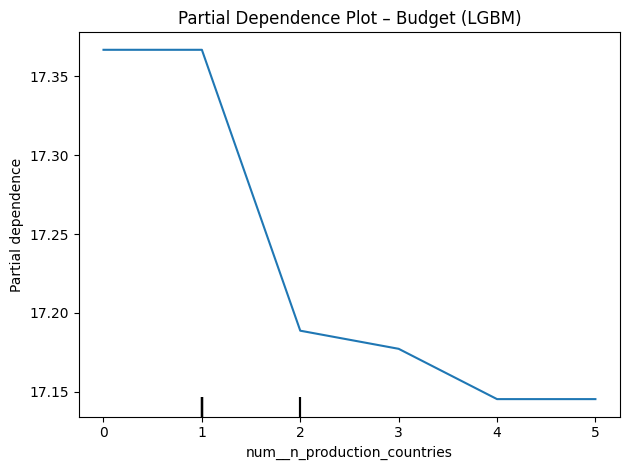

In [16]:
import sys
from pathlib import Path

# --------------------------------------------------
# Project root
# --------------------------------------------------
project_root = Path.cwd().resolve().parents[1]
sys.path.insert(0, str(project_root))

# --------------------------------------------------
# Imports
# --------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from joblib import load
from sklearn.inspection import PartialDependenceDisplay

# --------------------------------------------------
# Paths
# --------------------------------------------------
evaluation_dir = project_root / "d100project" / "evaluation"

# --------------------------------------------------
# Load model & preprocessor
# --------------------------------------------------
lgbm_model = load(evaluation_dir / "lgbm_model.joblib")
preprocessor_lgbm = load(evaluation_dir / "lgbm_preprocessor.joblib")

print("Loaded LGBM model and preprocessor.")

# --------------------------------------------------
# Load evaluation data
# --------------------------------------------------
df = pd.read_parquet(evaluation_dir / "df_test_with_predictions.parquet")

# --------------------------------------------------
# Feature definitions (MUST match training)
# --------------------------------------------------
numeric_features = ["budget", "runtime", "year"]
list_features = ["genres_list"]
high_cardinality = ["original_language"]
count_features = [
    "n_production_companies",
    "n_production_countries",
    "n_spoken_languages"
]
month_feature = "month"

all_features = (
    numeric_features
    + list_features
    + [month_feature]
    + high_cardinality
    + count_features
)

X = df[all_features]

# --------------------------------------------------
# Transform data
# --------------------------------------------------
X_lgbm = preprocessor_lgbm.transform(X)

# --------------------------------------------------
# Get transformed feature names
# --------------------------------------------------
feature_names = preprocessor_lgbm.get_feature_names_out()

# --------------------------------------------------
# Select ONE feature for PDP (budget)
# --------------------------------------------------
# PDP must be done on transformed features
target_feature = "n_production_countries"

feature_name = [
    f for f in feature_names if target_feature in f.lower()
][0]

feature_index = list(feature_names).index(feature_name)

print(f"PDP feature: {feature_name} (index {feature_index})")

# --------------------------------------------------
# Plot PDP
# --------------------------------------------------
plt.figure(figsize=(8, 6))

PartialDependenceDisplay.from_estimator(
    lgbm_model,
    X_lgbm,
    features=[feature_index],
    feature_names=feature_names,
    grid_resolution=50
)

plt.title("Partial Dependence Plot – Budget (LGBM)")
plt.tight_layout()
plt.show()


Loaded LGBM model and preprocessor.
PDP feature: num__runtime (index 1)


/home/gmurp/miniconda3/envs/d100projectenv/lib/python3.12/site-packages/sklearn/pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/home/gmurp/miniconda3/envs/d100projectenv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/gmurp/miniconda3/envs/d100projectenv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/gmurp/miniconda3/envs/d100projectenv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home

<Figure size 800x600 with 0 Axes>

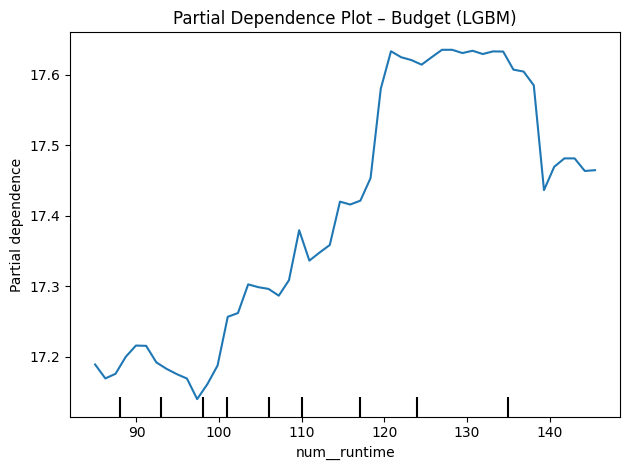

In [17]:
import sys
from pathlib import Path

# --------------------------------------------------
# Project root
# --------------------------------------------------
project_root = Path.cwd().resolve().parents[1]
sys.path.insert(0, str(project_root))

# --------------------------------------------------
# Imports
# --------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from joblib import load
from sklearn.inspection import PartialDependenceDisplay

# --------------------------------------------------
# Paths
# --------------------------------------------------
evaluation_dir = project_root / "d100project" / "evaluation"

# --------------------------------------------------
# Load model & preprocessor
# --------------------------------------------------
lgbm_model = load(evaluation_dir / "lgbm_model.joblib")
preprocessor_lgbm = load(evaluation_dir / "lgbm_preprocessor.joblib")

print("Loaded LGBM model and preprocessor.")

# --------------------------------------------------
# Load evaluation data
# --------------------------------------------------
df = pd.read_parquet(evaluation_dir / "df_test_with_predictions.parquet")

# --------------------------------------------------
# Feature definitions (MUST match training)
# --------------------------------------------------
numeric_features = ["budget", "runtime", "year"]
list_features = ["genres_list"]
high_cardinality = ["original_language"]
count_features = [
    "n_production_companies",
    "n_production_countries",
    "n_spoken_languages"
]
month_feature = "month"

all_features = (
    numeric_features
    + list_features
    + [month_feature]
    + high_cardinality
    + count_features
)

X = df[all_features]

# --------------------------------------------------
# Transform data
# --------------------------------------------------
X_lgbm = preprocessor_lgbm.transform(X)

# --------------------------------------------------
# Get transformed feature names
# --------------------------------------------------
feature_names = preprocessor_lgbm.get_feature_names_out()

# --------------------------------------------------
# Select ONE feature for PDP (budget)
# --------------------------------------------------
# PDP must be done on transformed features
target_feature = "runtime"

feature_name = [
    f for f in feature_names if target_feature in f.lower()
][0]

feature_index = list(feature_names).index(feature_name)

print(f"PDP feature: {feature_name} (index {feature_index})")

# --------------------------------------------------
# Plot PDP
# --------------------------------------------------
plt.figure(figsize=(8, 6))

PartialDependenceDisplay.from_estimator(
    lgbm_model,
    X_lgbm,
    features=[feature_index],
    feature_names=feature_names,
    grid_resolution=50
)

plt.title("Partial Dependence Plot – Budget (LGBM)")
plt.tight_layout()
plt.show()

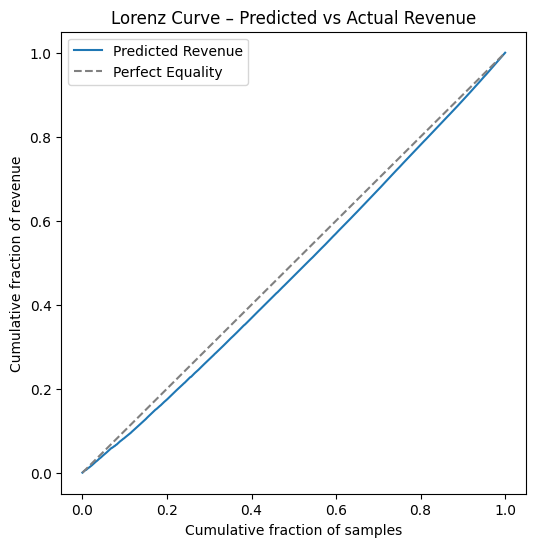

In [ ]:
from _evaluate_predictions import lorenz_curve
import numpy as np
import matplotlib.pyplot as plt

df_test = pd.read_parquet("df_test_with_predictions.parquet")

# Columns we will use
y_true = df_test['ln_revenue'].values
y_pred = df_test['pred_lgbm'].values   
exposure = df_test['budget'].values    # example exposure; replace if needed

exposure = np.ones_like(y_true)

cum_samples, cum_claims = lorenz_curve(y_true, y_pred, exposure)

import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.plot(cum_samples, cum_claims, label='Predicted Revenue')
plt.plot([0,1], [0,1], '--', color='gray', label='Perfect Equality')
plt.xlabel("Cumulative fraction of samples")
plt.ylabel("Cumulative fraction of revenue")
plt.title("Lorenz Curve – Predicted vs Actual Revenue")
plt.legend()
plt.show()

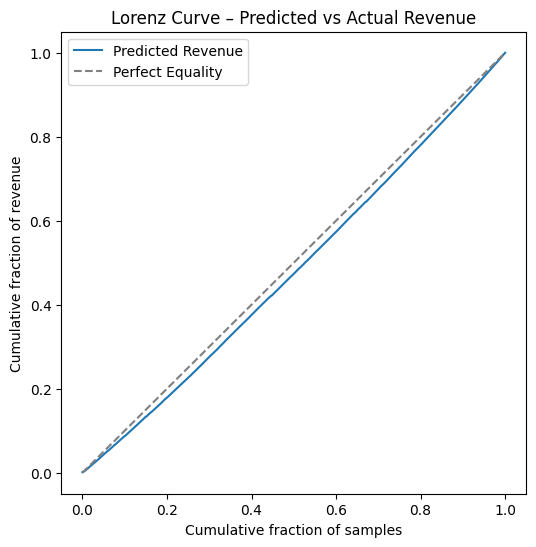

In [19]:
from _evaluate_predictions import lorenz_curve
import numpy as np
import matplotlib.pyplot as plt

df_test = pd.read_parquet("df_test_with_predictions.parquet")

# Columns we will use
y_true = df_test['ln_revenue'].values
y_pred = df_test['pred_glm'].values   
exposure = df_test['budget'].values    # example exposure; replace if needed

exposure = np.ones_like(y_true)

cum_samples, cum_claims = lorenz_curve(y_true, y_pred, exposure)

import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.plot(cum_samples, cum_claims, label='Predicted Revenue')
plt.plot([0,1], [0,1], '--', color='gray', label='Perfect Equality')
plt.xlabel("Cumulative fraction of samples")
plt.ylabel("Cumulative fraction of revenue")
plt.title("Lorenz Curve – Predicted vs Actual Revenue")
plt.legend()
plt.show()